<a href="https://colab.research.google.com/github/nenurd44/just_a_trash/blob/main/comparing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -U transformers accelerate datasets soundfile librosa faster-whisper jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
  

In [5]:
import pandas as pd
from jiwer import wer, cer
import time
import re

audios = [
    {
        "file": "test.wav",
        "text": "I am in the computer lab, you may come in.",
        "lang": "en"
    },
    {
        "file": "test2.wav",
        "text": "Hello, my name is Nurassyl and now I'm studying and Nazarbayev University.",
        "lang": "en"
    },
    {
        "file": "test3.wav",
        "text": "Hello hello, today we gonna do speech to text converter.",
        "lang": "en"
    },
    {
        "file": "test4.wav",
        "text": "Hello, my name is Baurzhan. I'm from Kazakhstan.",
        "lang": "en"
    },

]

results = []

def basic_clean(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return " ".join(text.split())

def record_result(model_name, audio, pred, duration):
    audio["text"] = basic_clean(audio["text"])
    prediction = basic_clean(pred)

    results.append({
        "Model": model_name,
        "File": audio["file"],
        "Language": audio["lang"],
        "Real": audio["text"],
        "Predicted": prediction.strip(),
        "WER": round(wer(audio["text"], prediction), 4),
        "CER": round(cer(audio["text"], prediction), 4),
        "Time_Sec": round(duration, 2)
    })

In [7]:
import torch
from transformers import pipeline

whisper_pipe = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-large-v3",
    torch_dtype=torch.float16,
    device="cuda"
)

for audio in audios:
    start = time.time()
    output = whisper_pipe(audio["file"])
    record_result("Whisper-v3", audio, output["text"], time.time() - start)

del whisper_pipe
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits pr

In [8]:
from faster_whisper import WhisperModel
import time

model_speed = WhisperModel("large-v3", device="cuda", compute_type="float16")

for audio in audios:
    start = time.time()

    segments, info = model_speed.transcribe(audio["file"], beam_size=1)

    pred = "".join([segment.text for segment in segments])

    record_result("Faster-Whisper-V3", audio, pred, time.time() - start)

del model_speed
torch.cuda.empty_cache()

In [9]:
import torch
from transformers import pipeline

whisper_turbo = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-large-v3-turbo",
    torch_dtype=torch.float16,
    device="cuda"
)

for audio in audios:
    start = time.time()
    result = whisper_turbo(audio["file"])
    record_result("Whisper-Turbo", audio, result["text"], time.time() - start)

del whisper_turbo
torch.cuda.empty_cache()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

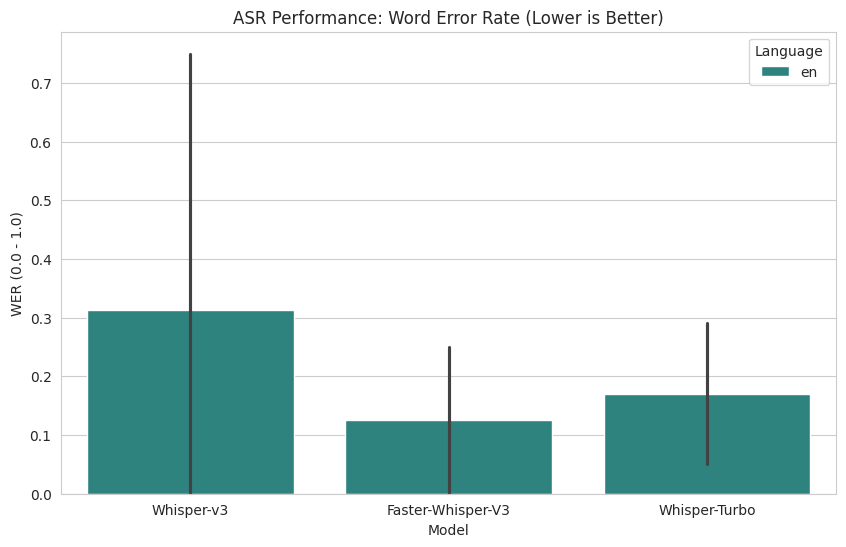

,Model,Language,WER,CER,Time_Sec,Predicted
0,Whisper-Turbo,en,0.0000,0.0000,1.13,i am in the computer lab you may come in
1,Faster-Whisper-V3,en,0.0000,0.0000,1.15,hello hello today we gonna do speech to text c...
2,Whisper-v3,en,0.0000,0.0000,1.20,hello hello today we gonna do speech to text c...
3,Faster-Whisper-V3,en,0.0000,0.0000,1.60,i am in the computer lab you may come in
4,Whisper-v3,en,0.0000,0.0000,4.51,i am in the computer lab you may come in
5,Whisper-Turbo,en,0.1000,0.0370,0.57,hello hello today were gonna do speech to text...
6,Faster-Whisper-V3,en,0.2500,0.0845,1.15,hello my name is noro sol and now im studying ...
7,Whisper-v3,en,0.2500,0.0845,1.60,hello my name is noro sol and now im studying ...
8,Faster-Whisper-V3,en,0.2500,0.0909,1.18,hello my name is pao zhang im from kazakhstan
9,Whisper-Turbo,en,0.2500,0.1136,0.55,hello my name is paul jean im from kazakhstan


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
plot = sns.barplot(data=df, x="Model", y="WER", hue="Language", palette="viridis")
plt.title("ASR Performance: Word Error Rate (Lower is Better)")
plt.ylabel("WER (0.0 - 1.0)")
plt.show()

df_sorted = df.sort_values(by=["WER", "CER", "Time_Sec"], ascending=[True, True, True])

display(df_sorted[["Model", "Language", "WER", "CER", "Time_Sec", "Predicted"]].reset_index(drop=True))

In [ ]:
# trash dalwe

In [1]:
# !pip install jiwer
# from jiwer import wer, cer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.4 MB/s eta 0:00:00


In [3]:
# org = "hello my name is baurzhan im from kazakhstan"
# pred = "hello my name is pao zhang im from kazakhstan"
# print(round(wer(org, pred), 4))

0.25


In [1]:
# from nemo.collections.asr.models import EncDecMultiTaskModel

# canary_model = EncDecMultiTaskModel.from_pretrained('nvidia/canary-1b')
# canary_model.to("cuda")

# for audio in audios:
#     start_time = time.time()
#     res = canary_model.transcribe(
#         paths2audio_files=[audio["file"]],
#         task="asr",
#         source_lang=audio["lang"],
#         batch_size=1
#     )

#     prediction = res[0] if isinstance(res, list) else res

#     record_result("Canary-1B", audio, prediction, time.time() - start_time)

# del canary_model
# torch.cuda.empty_cache()
